/tmp/ipykernel_318395/352858938.py:61: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


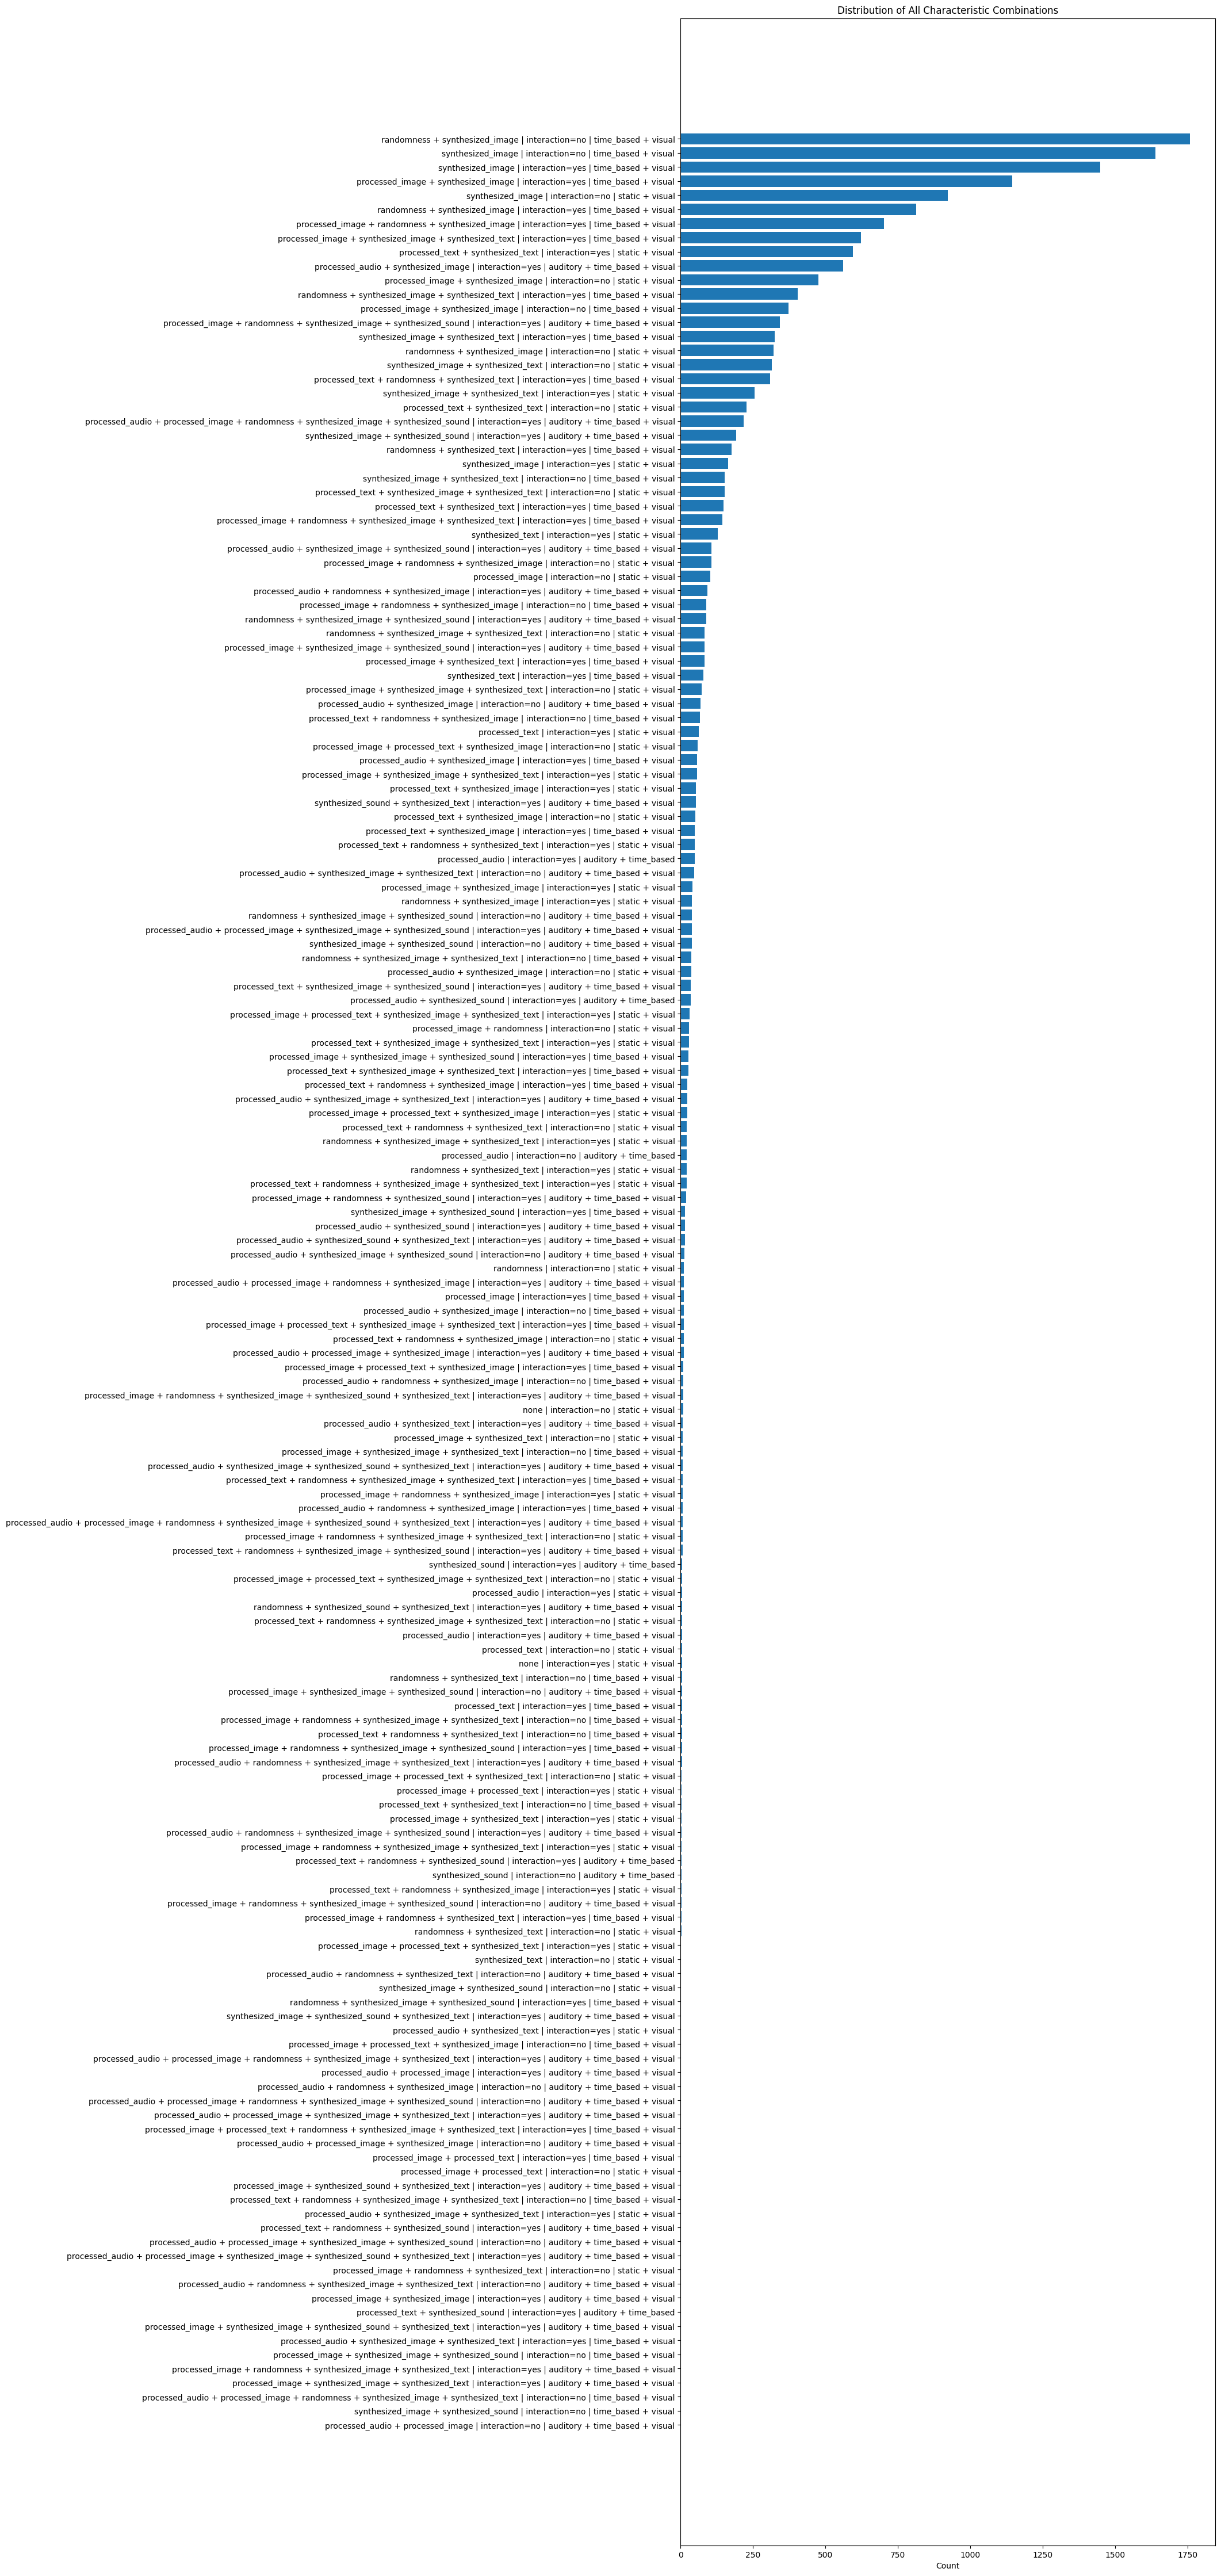

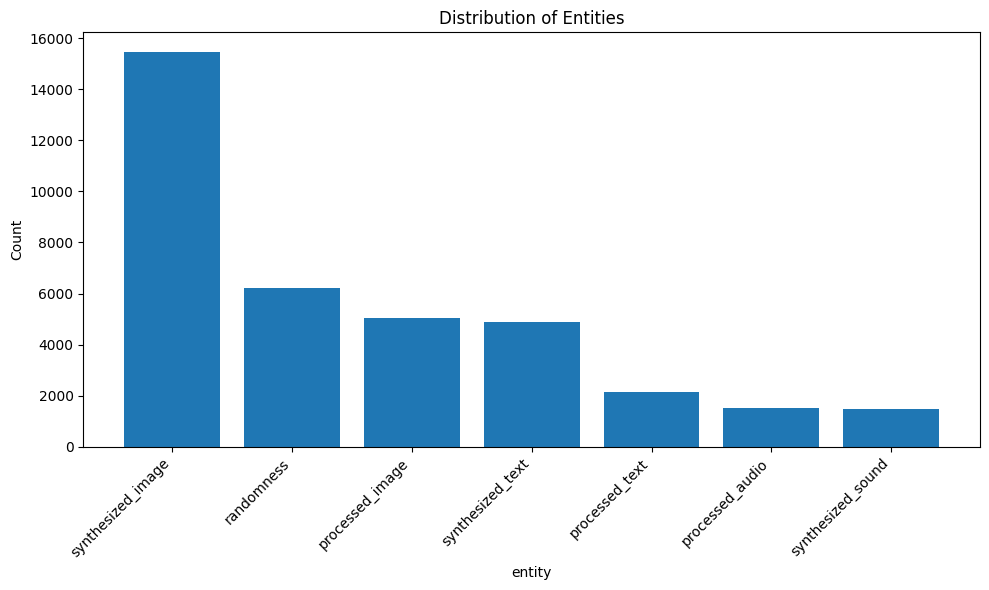

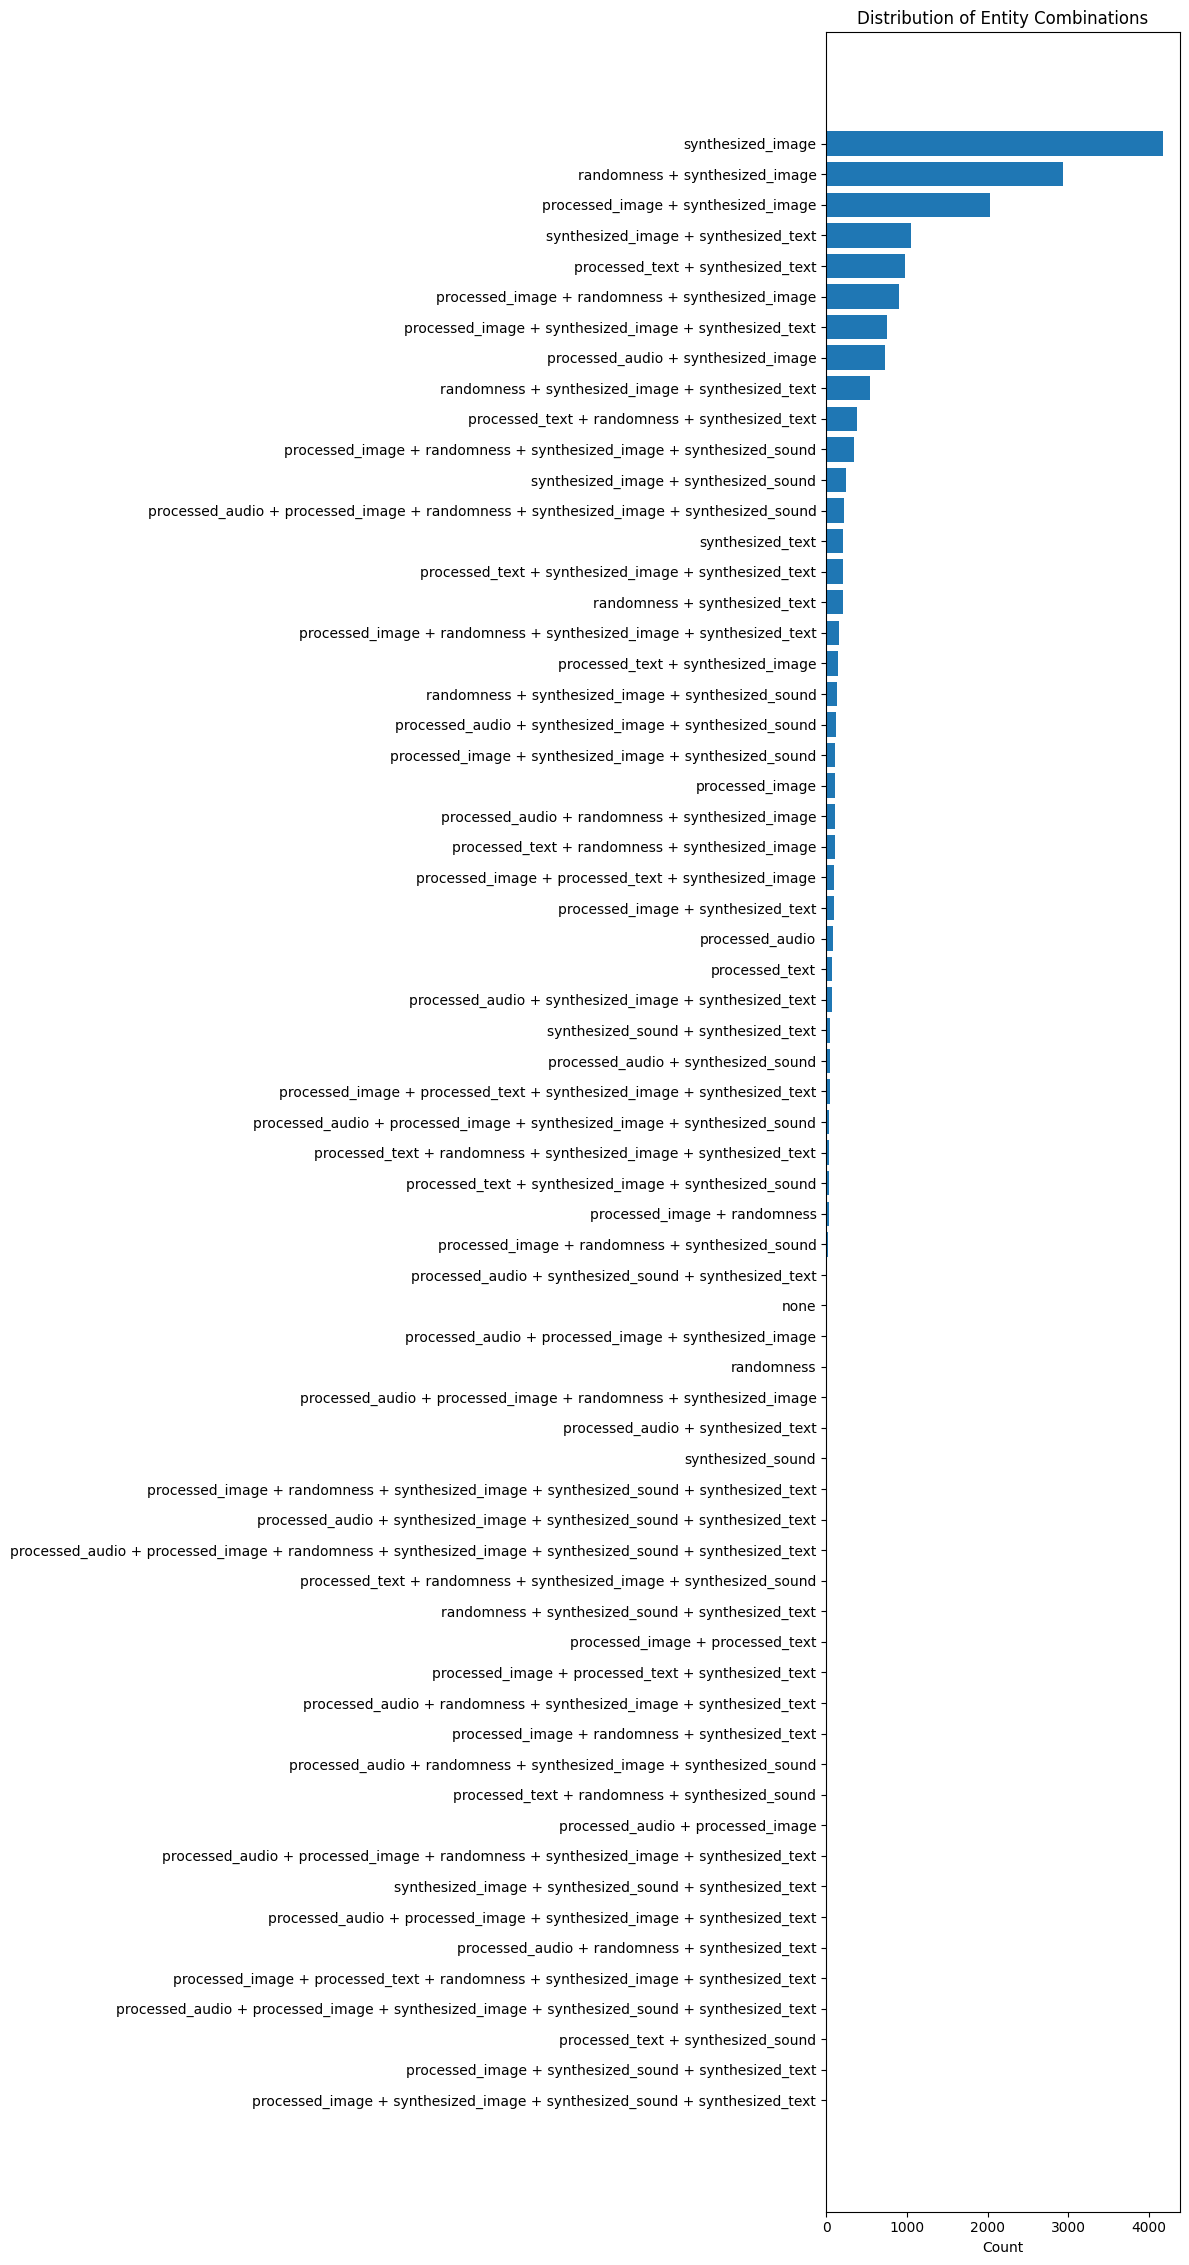

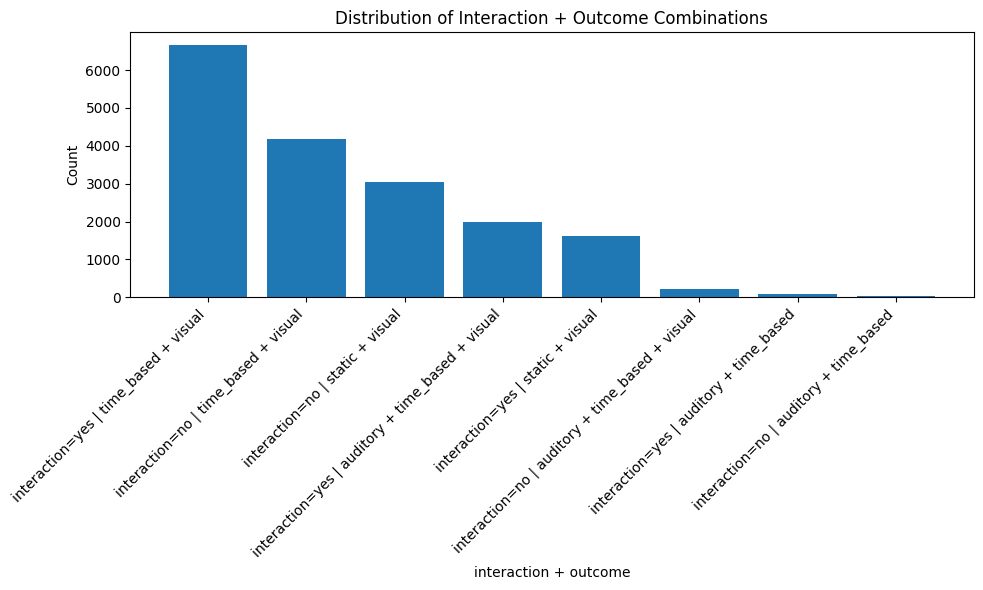

(                                           combination  count
 6    randomness + synthesized_image | interaction=n...   1758
 14   synthesized_image | interaction=no | time_base...   1638
 16   synthesized_image | interaction=yes | time_bas...   1448
 5    processed_image + synthesized_image | interact...   1145
 21   synthesized_image | interaction=no | static + ...    922
 ..                                                 ...    ...
 155  processed_audio + synthesized_image + synthesi...      1
 159  processed_text + randomness + synthesized_soun...      1
 160  processed_audio + processed_image + synthesize...      1
 161  processed_audio + processed_image + synthesize...      1
 162  processed_image + randomness + synthesized_tex...      1
 
 [163 rows x 2 columns],
               entity  count
 1  synthesized_image  15458
 2         randomness   6208
 0    processed_image   5053
 4   synthesized_text   4884
 6     processed_text   2138
 3    processed_audio   1517
 5  synthesize

In [3]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

# PREDICTIONS_FILE = Path("../artworks/PROMPT_10f_20260603/clean_artworks_label_prediction.json")
PREDICTIONS_FILE = Path("../artworks/PROMPT_10e_20260531/clean_artworks_label_prediction.json")


def load_predictions(path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def labels_key(item):
    return item["predicted_labels"]


def sorted_join(values):
    return " + ".join(sorted(values))


def all_characteristics_combo(labels):
    entities = sorted_join(labels.get("entities", [])) or "none"
    interaction = labels.get("interaction", ["none"])[0]
    outcome = sorted_join(labels.get("outcome", [])) or "none"

    return f"{entities} | interaction={interaction} | {outcome}"


def interaction_outcome_combo(labels):
    interaction = labels.get("interaction", ["none"])[0]
    outcome = sorted_join(labels.get("outcome", [])) or "none"

    return f"interaction={interaction} | {outcome}"


def entities_combo(labels):
    entities = sorted_join(labels.get("entities", [])) or "none"
    return entities


def plot_counts_horizontal(counter, title, xlabel, top_n=None):
    df = pd.DataFrame(counter.items(), columns=[xlabel, "count"])
    df = df.sort_values("count", ascending=False)

    if top_n is not None:
        df = df.head(top_n)

    plot_df = df.sort_values("count", ascending=True)

    fig, ax = plt.subplots(figsize=(12, max(4, len(plot_df) * 0.35)))

    ax.barh(plot_df[xlabel], plot_df["count"])
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.set_ylabel("")

    fig.tight_layout()
    plt.show()

    return df


def plot_counts_vertical(counter, title, xlabel, top_n=None):
    df = pd.DataFrame(counter.items(), columns=[xlabel, "count"])
    df = df.sort_values("count", ascending=False)

    if top_n is not None:
        df = df.head(top_n)

    fig, ax = plt.subplots(figsize=(max(10, len(df) * 0.45), 6))

    ax.bar(df[xlabel], df["count"])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")

    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")

    fig.tight_layout()
    plt.show()

    return df


predictions = load_predictions(PREDICTIONS_FILE)
labels = [labels_key(item) for item in predictions]


# 1. Distribution of all combinations of characteristics
# Horizontal because this plot has many long labels.
all_combo_counts = Counter(all_characteristics_combo(x) for x in labels)

df_all_combos = plot_counts_horizontal(
    all_combo_counts,
    title="Distribution of All Characteristic Combinations",
    xlabel="combination",
    top_n=1000,
)


# 2. Distribution of entities
entity_counts = Counter()

for x in labels:
    entity_counts.update(x.get("entities", []))

df_entities = plot_counts_vertical(
    entity_counts,
    title="Distribution of Entities",
    xlabel="entity",
)


# 2.1 Distribution of entity combinations
entity_combo_counts = Counter(entities_combo(x) for x in labels)

# df_entity_combos = plot_counts_vertical(
#     entity_combo_counts,
#     title="Distribution of Entity Combinations",
#     xlabel="entity combination",
#     top_n=1000,
# )

df_entity_combos = plot_counts_horizontal(
    entity_combo_counts,
    title="Distribution of Entity Combinations",
    xlabel="entity combination",
    top_n=1000,
)

# 3. Distribution of interaction + outcome combinations
interaction_outcome_counts = Counter(interaction_outcome_combo(x) for x in labels)

df_interaction_outcome = plot_counts_vertical(
    interaction_outcome_counts,
    title="Distribution of Interaction + Outcome Combinations",
    xlabel="interaction + outcome",
)


df_all_combos, df_entities, df_entity_combos, df_interaction_outcome

/tmp/ipykernel_318395/1567878081.py:61: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


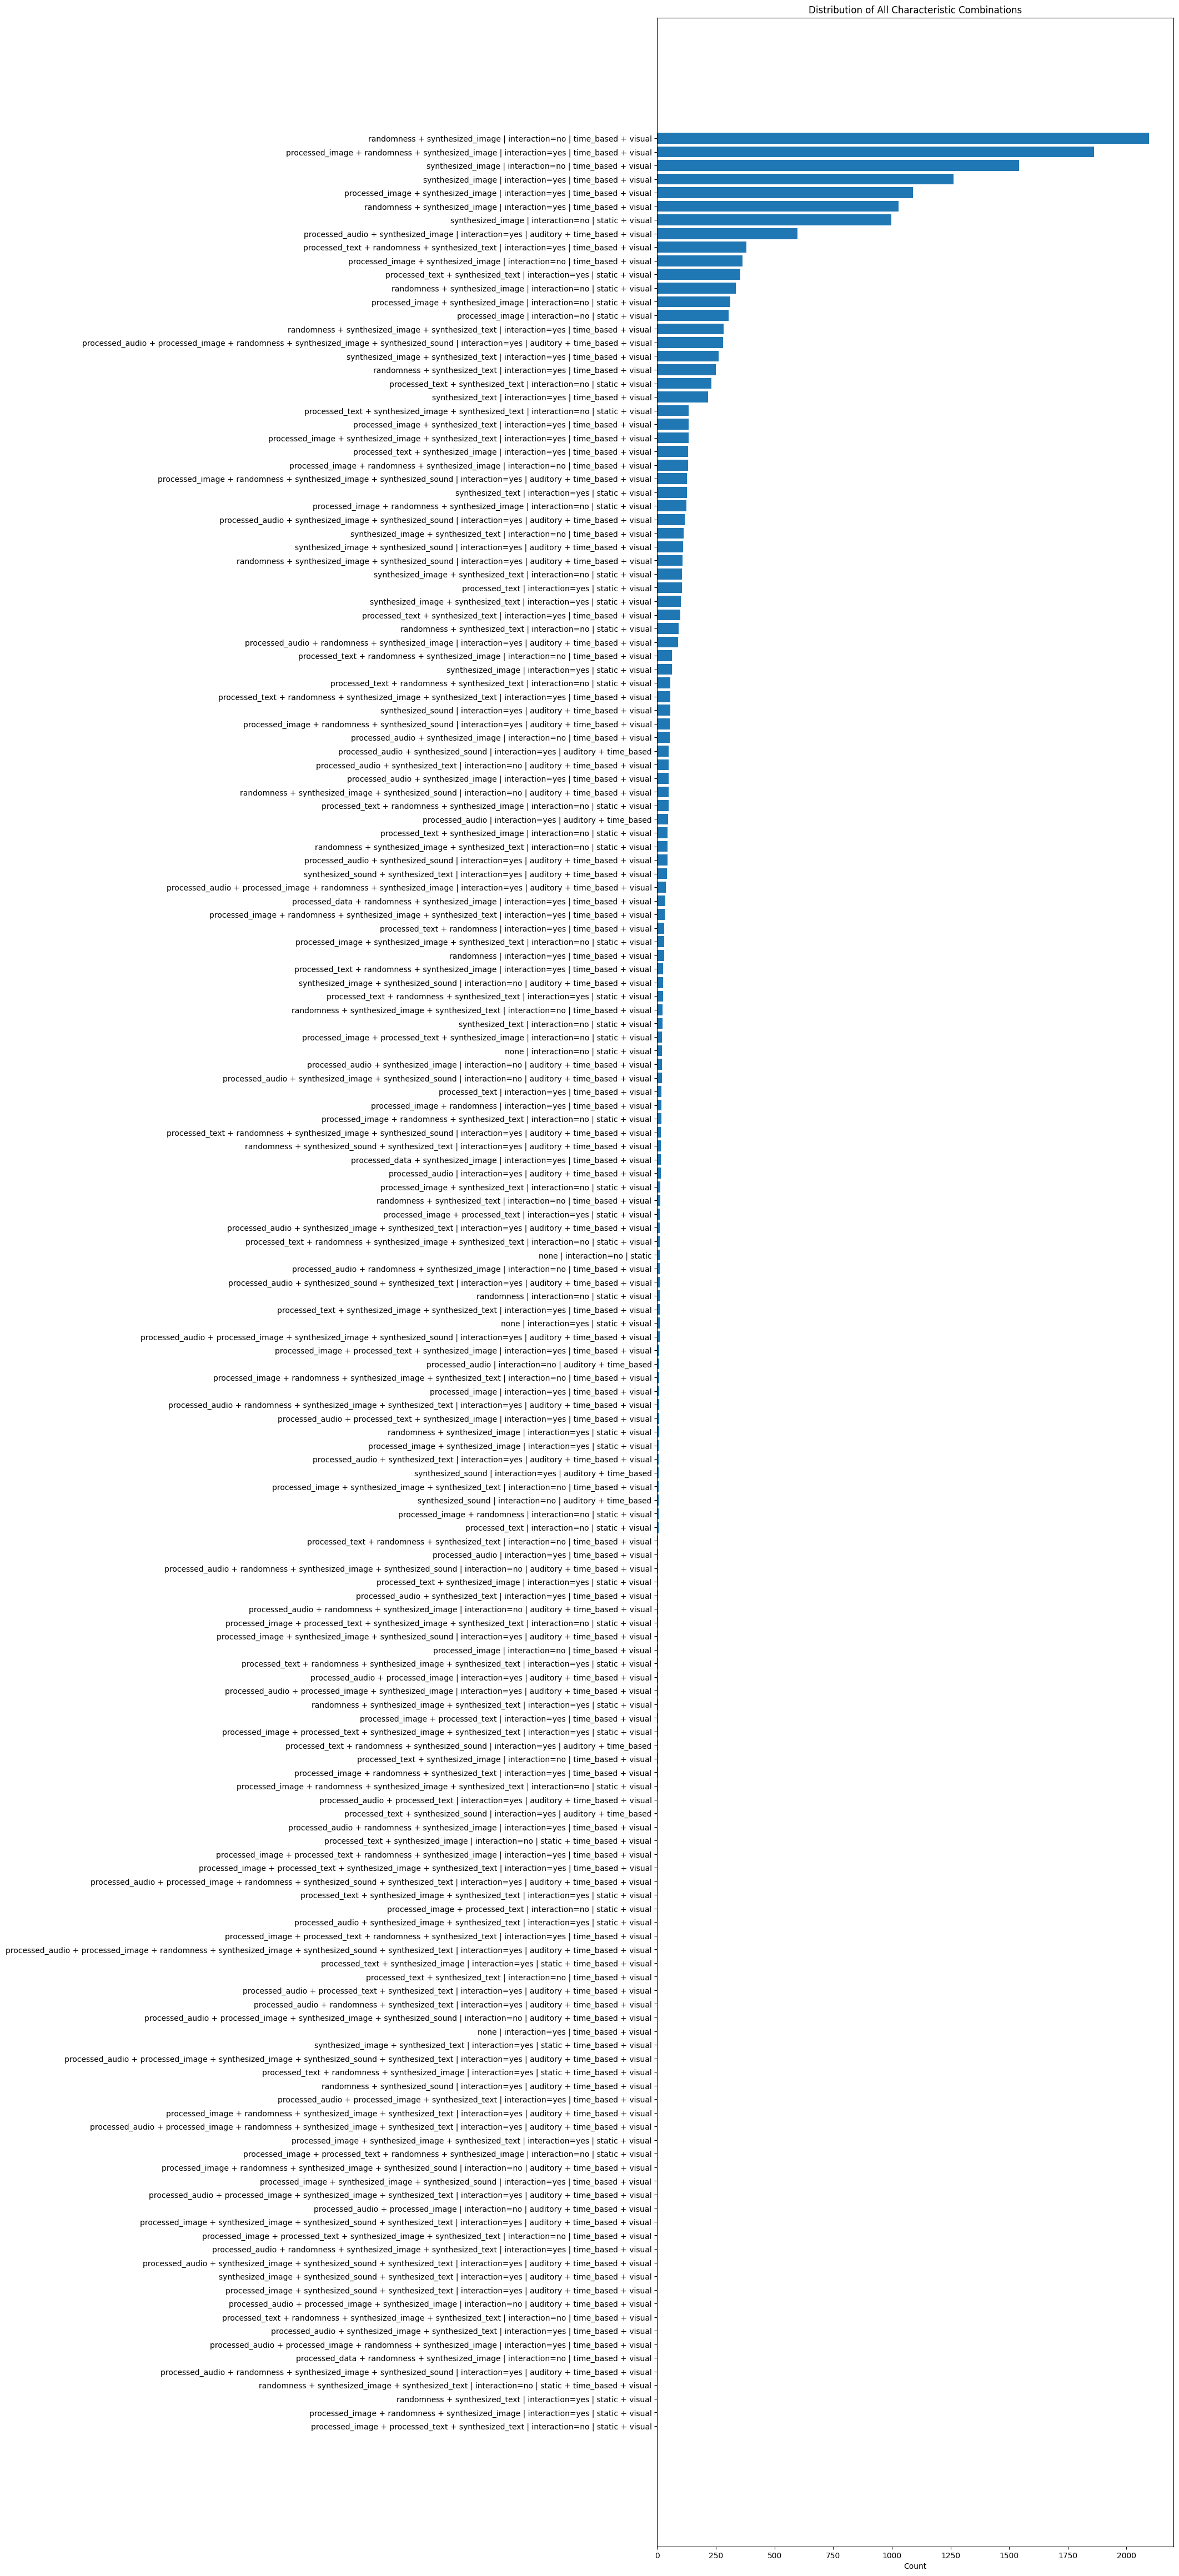

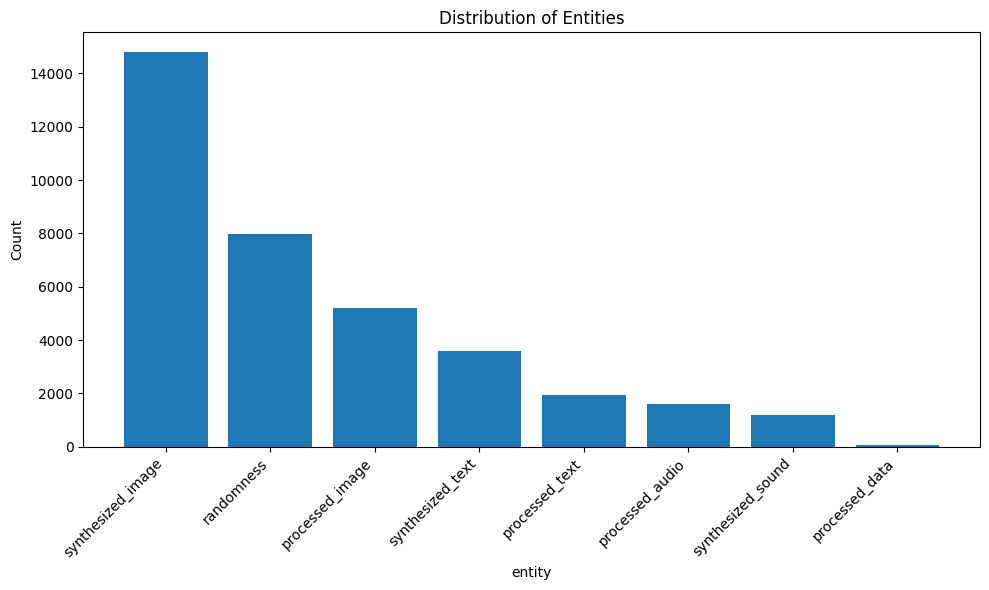

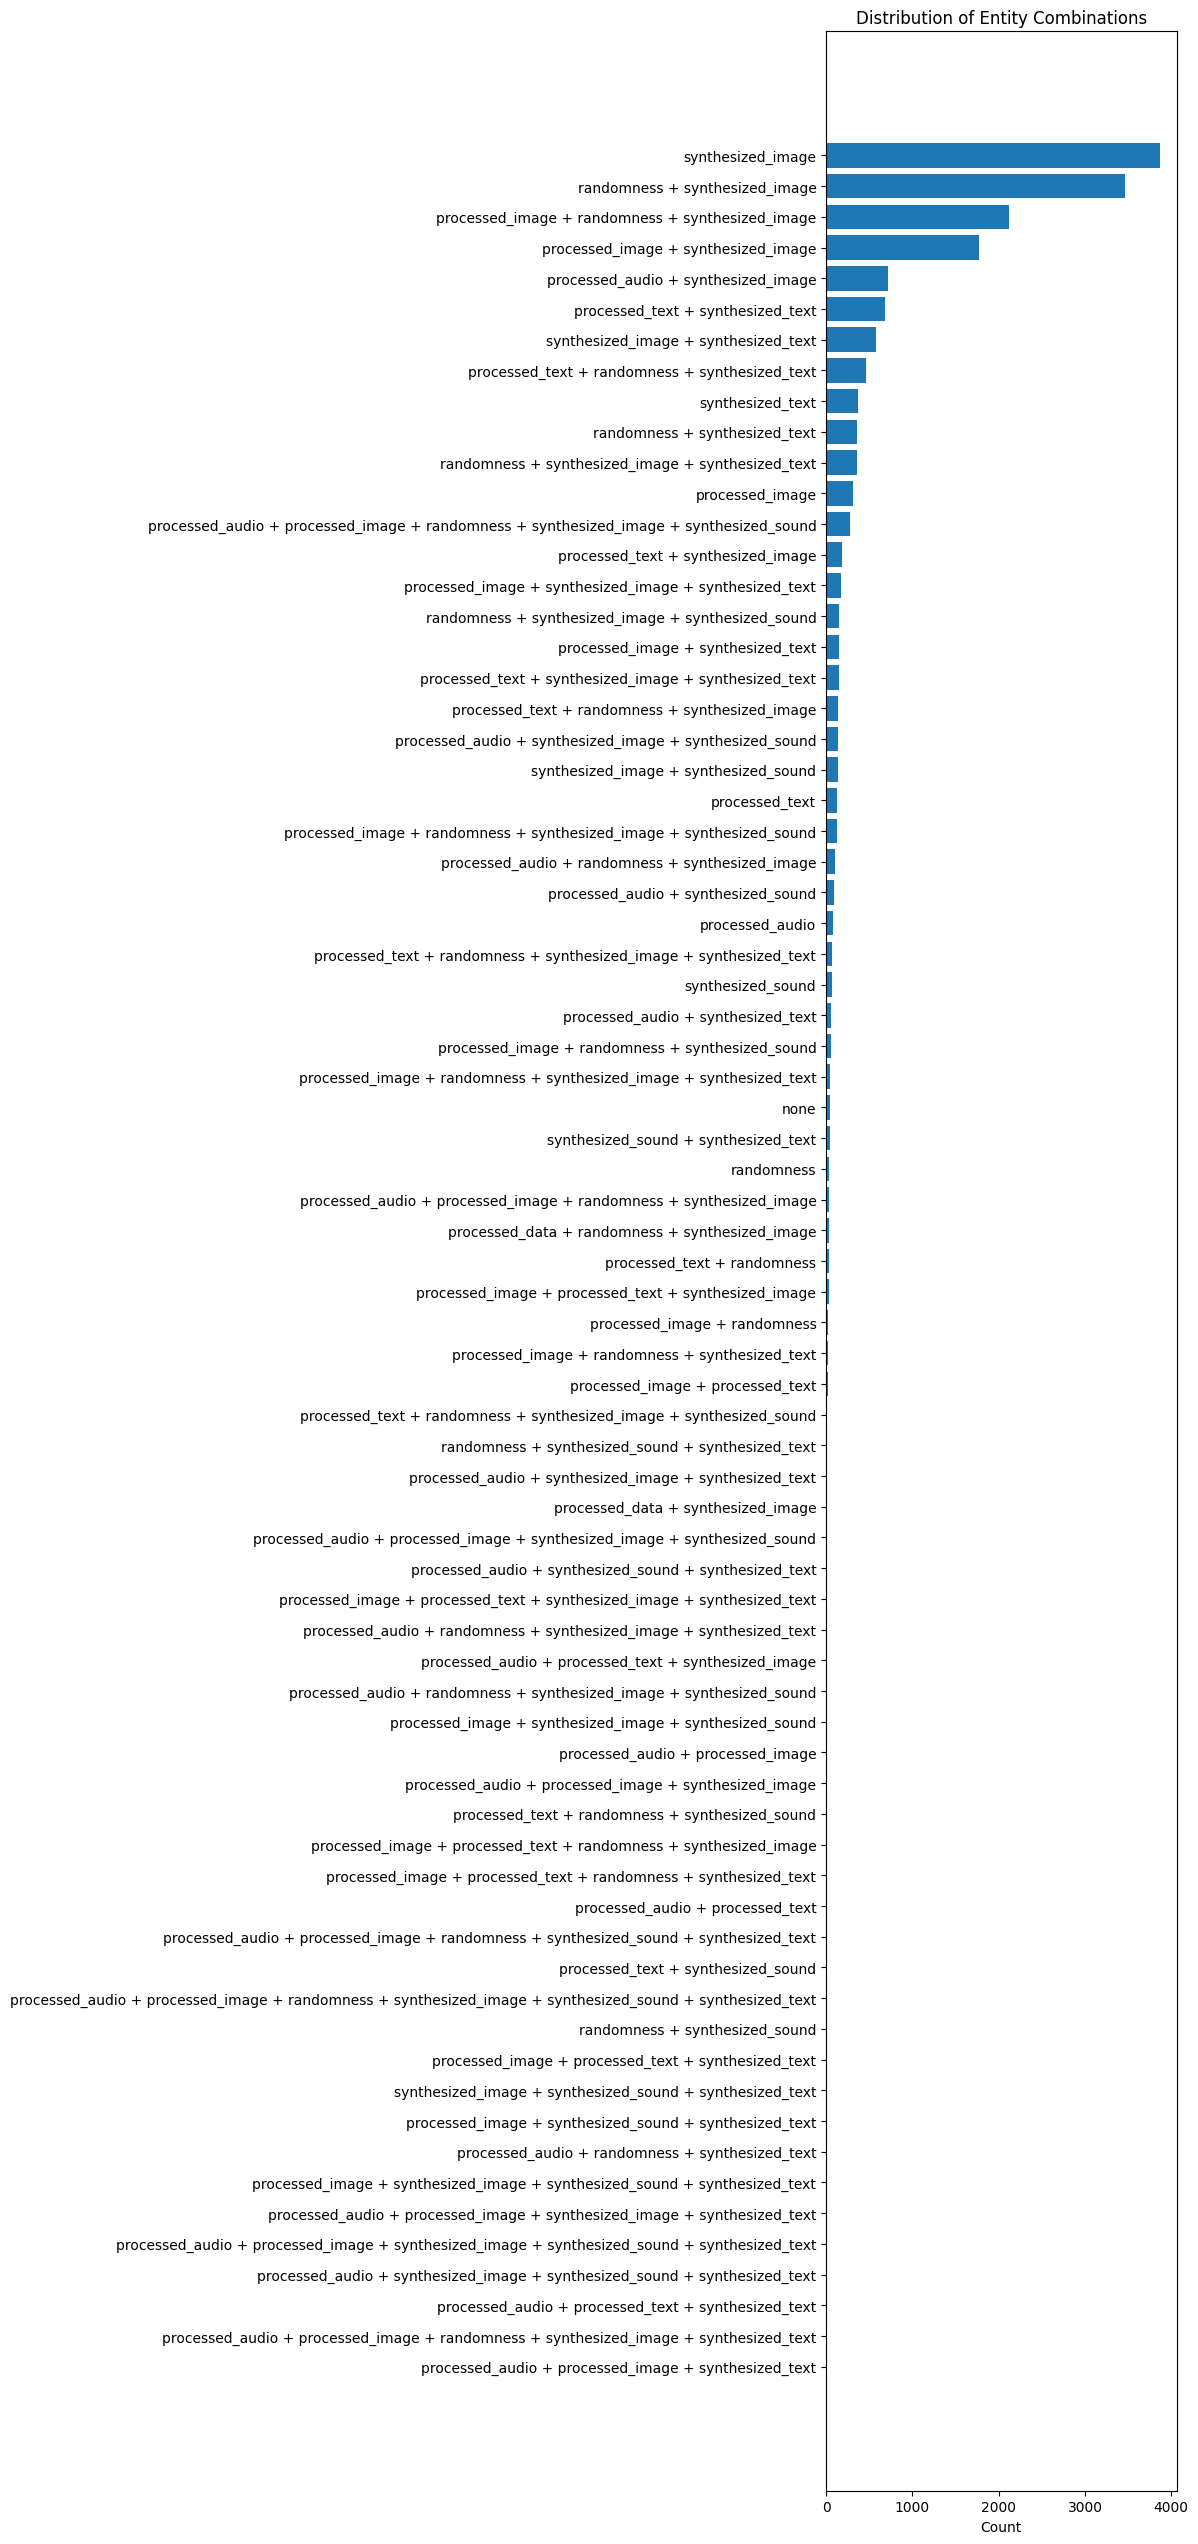

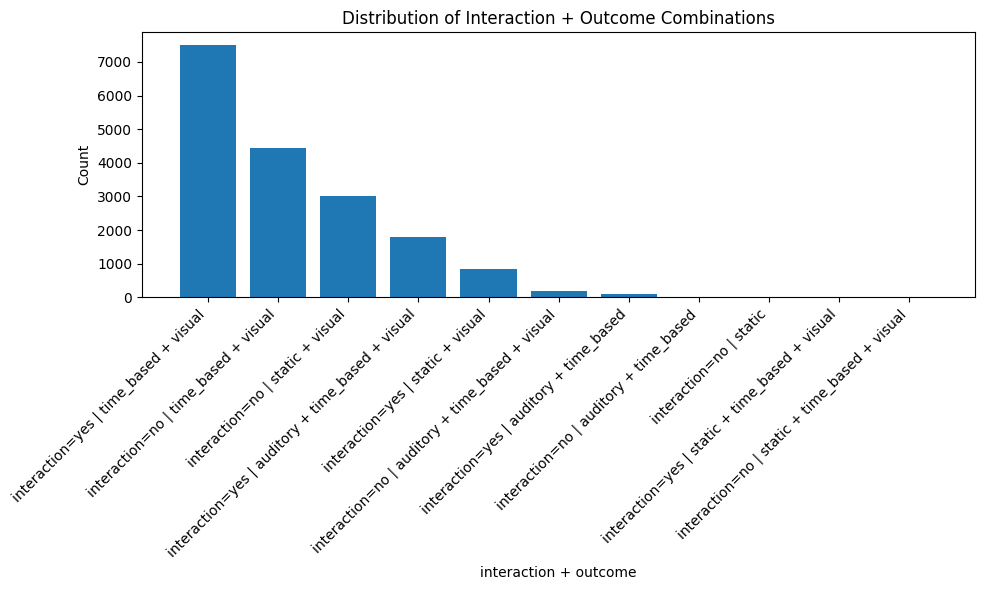

(                                           combination  count
 14   randomness + synthesized_image | interaction=n...   2096
 5    processed_image + randomness + synthesized_ima...   1861
 22   synthesized_image | interaction=no | time_base...   1543
 13   synthesized_image | interaction=yes | time_bas...   1264
 4    processed_image + synthesized_image | interact...   1091
 ..                                                 ...    ...
 162  processed_audio + randomness + synthesized_ima...      1
 164  processed_data + randomness + synthesized_imag...      1
 166       none | interaction=yes | time_based + visual      1
 167  processed_audio + processed_image + synthesize...      1
 168  processed_audio + randomness + synthesized_tex...      1
 
 [169 rows x 2 columns],
               entity  count
 0  synthesized_image  14803
 1         randomness   7994
 2    processed_image   5212
 5   synthesized_text   3590
 6     processed_text   1951
 3    processed_audio   1589
 4  synthesize

In [2]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

PREDICTIONS_FILE = Path("../artworks/PROMPT_10f_20260603/clean_artworks_label_prediction.json")
# PREDICTIONS_FILE = Path("../artworks/PROMPT_10e_20260531/clean_artworks_label_prediction.json")

predictions = load_predictions(PREDICTIONS_FILE)
labels = [labels_key(item) for item in predictions]


# 1. Distribution of all combinations of characteristics
# Horizontal because this plot has many long labels.
all_combo_counts = Counter(all_characteristics_combo(x) for x in labels)

df_all_combos = plot_counts_horizontal(
    all_combo_counts,
    title="Distribution of All Characteristic Combinations",
    xlabel="combination",
    top_n=1000,
)


# 2. Distribution of entities
entity_counts = Counter()

for x in labels:
    entity_counts.update(x.get("entities", []))

df_entities = plot_counts_vertical(
    entity_counts,
    title="Distribution of Entities",
    xlabel="entity",
)


# 2.1 Distribution of entity combinations
entity_combo_counts = Counter(entities_combo(x) for x in labels)

# df_entity_combos = plot_counts_vertical(
#     entity_combo_counts,
#     title="Distribution of Entity Combinations",
#     xlabel="entity combination",
#     top_n=1000,
# )

df_entity_combos = plot_counts_horizontal(
    entity_combo_counts,
    title="Distribution of Entity Combinations",
    xlabel="entity combination",
    top_n=1000,
)

# 3. Distribution of interaction + outcome combinations
interaction_outcome_counts = Counter(interaction_outcome_combo(x) for x in labels)

df_interaction_outcome = plot_counts_vertical(
    interaction_outcome_counts,
    title="Distribution of Interaction + Outcome Combinations",
    xlabel="interaction + outcome",
)


df_all_combos, df_entities, df_entity_combos, df_interaction_outcome